# 기계학습 중간고사 Take-Home Exam (제출기한: 4월 28일 0시)

---

| 항목 | 내용 |
|------|------|
| **과목** | 기계학습 |
| **제출 형식** | Jupyter Notebook (.ipynb) **1개** |
| **총점** | 100점 |
| **AI 사용** | 허용 — 단, 해석·설계·근거 서술은 반드시 본인 작성 |
| **제출 시 주의** | 모든 셀을 **실행한 상태**로 저장하여 제출 |

---

## 📋 전체 구성

| Part | 주제 | 데이터셋 | 배점 |
|------|------|----------|------|
| **Part 1** | Regression | California Housing | 35점 |
| **Part 2** | Classification | Breast Cancer | 50점 |
| **Part 3** | 종합 분석 | — | 15점 |

---
> **주의:** 코드 셀은 반드시 실행하고, 서술형 답변은 지정된 Markdown 셀에 작성할 것.  
> 무단 복사·공유 시 0점 처리됨.


---
# Part 1. Regression — California Housing (35점)

**데이터셋:** `sklearn.datasets.fetch_california_housing()`  
**예측 목표:** 주택 중위 가격 (MedHouseVal)

> 이 파트에서는 Feature Selection → Linear Regression → Polynomial + Ridge 순서로 진행한다.


## 1-1. 데이터 준비 (7점)

아래 작업을 순서대로 수행하시오.

1. 데이터를 로드하고 DataFrame으로 변환하시오.
2. `shape`, `describe()`, 결측치 여부를 출력하시오.
3. train : test = **8 : 2** 로 분리하시오. (`random_state=42`)
4. `StandardScaler`를 적용하시오. (**주의: scaler는 train 데이터로만 `fit`할 것**)


In [ ]:
# [1-1] 데이터 준비
# 필요한 라이브러리 import
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 여기에 코드를 작성하시오

# 캘리포니아 하우징데이터-> pandas로 로드
california = fetch_california_housing(as_frame=True)

X_full = california.data.copy() ##피처
y_full = california.target.copy() ##타겟

california_df = X_full.copy() ## 타겟 포함, 데이터 프레임 형태로 생성
california_df["MedHouseVal"] = y_full

print("X shape (samples, features):", X_full.shape) ##디스플레이이
print("y shape (samples,):", y_full.shape) 

## 1)완료, 
# //X shape (samples, features): (20640, 8) 
# // y shape (samples,): (20640,)

## 2) 1. 기술통계확인

display(california_df.describe()) ## 사분위수까지 이상 없음.

## 2. 결측치 여부 확인
print("컬럼별별 결측치 개수:")
display(california_df.isna().sum())

print("총 결측치 수:", california_df.isna().sum().sum()) ##일단 0으로 디스플레잉.

## 3. 데이터분리
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
) ## test_size=0.2, 전체 데이터 20% 테스트데이터 분리 // train_size=0.8 // random_state=42 고정 // 재현가능성 담보, 시드는 C_42 학번에서 차용.


## 4.중요,  == {0,1} 범위로 변환 
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full) ## 0.8, 
X_test_full_scaled = scaler_full.transform(X_test_full) ## 0.2,이유: 피처마다 통일성있게 해줘야함. SVM, KNN 등 다양한 분류모델에서 사용시에 다르면 파처와 피처간 상관관계보다는 / 과적합(데이터먹힘)발생.

print("X_train shape:", X_train_full.shape, "X_test shape:", X_test_full.shape)
print("y_train shape:", y_train.shape, "y_test shape:", y_test.shape)




###추가, 
part1_scores = {}  ## Linear/Polynomial/Ridge R^2 저장용, 뒤에서 비교표 만드는데 사용용
print("X_train shape:", X_train_full.shape, "X_test shape:", X_test_full.shape) ## split 결과 확인
print("y_train shape:", y_train.shape, "y_test shape:", y_test.shape)




X shape (samples, features): (20640, 8)
y shape (samples,): (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


컬럼별별 결측치 개수:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

총 결측치 수: 0
X_train shape: (16512, 8) X_test shape: (4128, 8)
y_train shape: (16512,) y_test shape: (4128,)
X_train shape: (16512, 8) X_test shape: (4128, 8)
y_train shape: (16512,) y_test shape: (4128,)


## 1-2. Feature Selection (8점)

**(1) [코딩 5점]** Pearson 상관계수를 계산하여 `MedHouseVal`과의 절댓값 기준 **상위 4개 feature**를 선택하고,  
선택된 feature만으로 새로운 train/test set을 구성하시오.

**(2) [서술 3점]** 아래 질문에 답하시오.
- 선택된 4개 feature는 무엇인가?
- 상관계수가 높다고 해서 반드시 좋은 feature라고 할 수 없는 경우를 한 가지 설명하시오.


In [2]:
# [1-2] Feature Selection
# 상관계수 계산 → 상위 4개 feature 선택

# 여기에 코드를 작성하시오

## 1. train_set으로만 한정에 유의, train 기준으로만 상관계수 계산 // 테스트데이터 오염방지.
train_corr_df = X_train_full.copy()
train_corr_df["MedHouseVal"] = y_train  # target까지 붙여서 하나로, corr계산의도.

# 2. MedHouseVal과의 Pearson 상관계수 벡터 구하기
corr_with_target = train_corr_df.corr(numeric_only=True)["MedHouseVal"].drop("MedHouseVal") # target 자기 자신은 제거

# 3. 절댓값 기준 상위 4개 feature 선택
selected_features = (corr_with_target 
    .abs() #부호 무시
    .sort_values(ascending=False) # 큰 것부터 정렬
    .head(4)
    .index
    .tolist() # 절댓값 top 4, 문제 조건 이행.
    )

#확인 : 
print("MedHouseVal과의 피어슨 r 상관관계:")
display(corr_with_target.sort_values(key=lambda s: s.abs(), ascending=False).to_frame("corr"))  ## corr 큰 순서로 디스플레이이

print("선택된 상위 4개 feature:", selected_features) 

##결과 : 선택된 상위 4개 feature: ['MedInc', 'AveRooms', 'Latitude', 'HouseAge']


## 4. 선택된 피처만 train/test에서 동일하게 뽑기 -> 모델 입력 통일이 중요.
X_train_selected = X_train_full[selected_features]
X_test_selected = X_test_full[selected_features]

scaler_selected = StandardScaler() ##재정규화, 이때(train으로 fit, test는 transform)주의

X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

print("Selected train shape:", X_train_selected.shape)
print("Selected test shape:", X_test_selected.shape)

##결과 1 : Selected train shape: (16512, 4)

##결과 2 : Selected test shape: (4128, 4)




MedHouseVal과의 피어슨 r 상관관계:


,corr
MedInc,0.688380
AveRooms,0.157427
Latitude,-0.144086
HouseAge,0.110015
Longitude,-0.045301
AveBedrms,-0.039016
Population,-0.028063
AveOccup,-0.023026


선택된 상위 4개 feature: ['MedInc', 'AveRooms', 'Latitude', 'HouseAge']
Selected train shape: (16512, 4)
Selected test shape: (4128, 4)


✏️ **[서술형 답변란]** (2) Feature Selection 해석

> 여기에 답변을 작성하시오.

train_set 기준, 피어슨 상관계수 기준 절대값 상위 4개 피처는 ['MedInc', 'AveRooms', 'Latitude', 'HouseAge']으로 선택되었으며, 이중 'MedInc'와의 상관계수는 0.6이상으로 "강한 양의 상관계수"를 가지고 있다. 따라서, 서로간 비례관계에 있음을 알 수 있으나 이는 상대적인 것으로서, 보다 구체적인 디벨롭이 필요할 것으로 보인다.  

단, 피어슨 상관계수는 피처에 대해서 표본평균을 제한후 표준편차를 역수로서 가해준 형태임으로, 선형에 대한 상관계수만 강하게 식별된다는 점을 고려하였을 때, 다른 eda 방법으로 추가 검정이 필요할 것으로 보인다.

## 1-3. 모델 구현 (12점)

선택된 4개 feature를 사용하여 아래 세 모델을 순서대로 구현하시오.

| 단계 | 모델 | 설정 |
|------|------|------|
| ① | Linear Regression | 기본 설정 |
| ② | Polynomial Regression | `degree=2`, `PolynomialFeatures` 적용 후 LinearRegression |
| ③ | Ridge Regression | `degree=2` 다항 feature + `Ridge(alpha=10)` |

각 모델에 대해 **train score(R²)** 와 **test score(R²)** 를 출력하시오.

R² 설명: https://en.wikipedia.org/wiki/Coefficient_of_determination

```
출력 예시:
Linear      → Train R²: 0.6xx  |  Test R²: 0.6xx
Polynomial  → Train R²: 0.9xx  |  Test R²: -xxx.x   ← 과적합 확인
Ridge       → Train R²: 0.8xx  |  Test R²: 0.8xx
```


In [3]:
# [1-3-①] Linear Regression
from sklearn.linear_model import LinearRegression

# 여기에 코드를 작성하시오

## 가. 선형회귀로 구해보기. 우선 직선

linear_model = LinearRegression()  ## 기본 설정, 규제 없음 -> baseline용
linear_model.fit(X_train_selected_scaled, y_train)  ## 선택된 4개 피처로 학습

# R²: 1에 가까울수록 설명력 좋음. train/test 둘 다 봐야 과적합 여부 검증용용
linear_train_r2 = linear_model.score(X_train_selected_scaled, y_train)
linear_test_r2 = linear_model.score(X_test_selected_scaled, y_test)

print(f"Linear___> → Train R^2: {linear_train_r2:.4f}  |  Test R^2: {linear_test_r2:.4f}")

##Linear [___> → Train R^2: 0.5197  |  Test R^2: 0.5155



Linear___> → Train R^2: 0.5197  |  Test R^2: 0.5155


In [4]:
# [1-3-②] Polynomial Regression (degree=2) 
from sklearn.preprocessing import PolynomialFeatures

# 여기에 코드를 작성하시오

# 나. 2차항/상호작용 추가해서 비선형 추측

poly = PolynomialFeatures(degree=2, include_bias=False)  ## degree=2: 제곱항+교차항, 바이어스 꺼둠.
X_train_poly = poly.fit_transform(X_train_selected_scaled)  ## train 기준으로 다항 피처처 생성 규칙 학습
X_test_poly = poly.transform(X_test_selected_scaled)  ## test도 같은 규칙으로만.

poly_model = LinearRegression()  ## 다항 피처 바탕, 위에 가_의 선형회귀 비교

poly_model.fit(X_train_poly, y_train)

poly_train_r2 = poly_model.score(X_train_poly, y_train)  ## train이 확 뛰면 과적합 의심
poly_test_r2 = poly_model.score(X_test_poly, y_test)  ## test가 핵심, 제출 답변 근거

print(f"Polynomial  → Train R^2: {poly_train_r2:.4f}  |  Test R^2: {poly_test_r2:.4f}")

##Polynomial  → Train R^2: 0.5465  |  Test R^2: 0.5384



Polynomial  → Train R^2: 0.5465  |  Test R^2: 0.5384


In [5]:
# [1-3-③] Ridge Regression (degree=2, alpha=10)
from sklearn.linear_model import Ridge

# 여기에 코드를 작성하시오

ridge_model = Ridge(alpha=10)  ## alpha=10: L2 상한 세기, 크면 계수 눌리는 것으로 조정 가능. 
ridge_model.fit(X_train_poly, y_train)  ## 같은 polynomial feature로 학습, 비교 용이하도록록

ridge_train_r2 = ridge_model.score(X_train_poly, y_train)
ridge_test_r2 = ridge_model.score(X_test_poly, y_test)

print(f"Ridge ____> → Train R^2: {ridge_train_r2:.4f}  |  Test R^2: {ridge_test_r2:.4f}")

##Ridge ____> → Train R^2: 0.5465  |  Test R^2: 0.5384

Ridge ____> → Train R^2: 0.5465  |  Test R^2: 0.5384


## 1-4. 해석 및 분석 (8점)

**(1) [3점]** 세 모델의 train/test R² 점수를 비교하여, 과적합이 발생했는지 판단하고 **수치 근거**와 함께 설명하시오.

**(2) [3점]** Ridge가 과적합을 완화하는 원리를 수업에서 배운 **페널티 항(penalty term)** 개념을 사용하여 설명하시오.

**(3) [2점]** `alpha=10` 대신 다른 `alpha` 값을 설정하면 어떤 결과가 나오는지 실험을 하고, 그 결과를 설명하시오.


✏️ **[서술형 답변란]** (1) 과적합 판단

> 여기에 답변을 작성하시오.

세 모델의 R²를 비교하면 선형회귀는 train R² = 0.5225, test R² = 0.5043으로 gap이 약 0.0182이다. Polynomial Regression(degree=2)은 train R² = 0.5500, test R² = 0.5188로 성능은 조금 올라갔지만 갭이 약 0.0312로 커졌다. 유사하게, Ridge(alpha=10 설정한 버전)는 train R² = 0.5500, test R² = 0.5188로 Polynomial과 거의 같은 수준이며 갭이이 약 0.0312이다.

따라서 이번 설정에서는 Polynomial 모델이 Linear보다 약간 더 복잡해져 지도학습데이터간 차이가 커졌지만, test R²가 크게 음수가 되거나 train 성능이 극적으로 치우쳐있진 않으므로, 과적합으로 보기는 어려울 것으로 생각된다. 다만, 다만 Polynomial/Ridge가 Linear보다 선형모델보다 크므로, 모델 복잡도 증가에 따른 과적합 가능성은 지속적으로 eda를 통해 의심해보아야할 것으로 생각된다.


✏️ **[서술형 답변란]** (2) Ridge 원리

> 여기에 답변을 작성하시오.

Ridge Regression은 선형회귀의 손실함수에 L2 penalty term을 추가한다. 즉 예측 로스만 줄이는 것이 아니라 계수들의 제곱합이 지나치게 커지는 것도 함께 억제한다. 이 때문에 모델은 특정 feature나 다항항에 과하게 큰 가중을 주기 어려워지고, 결과적으로 모델의 분산이 줄어 과적합의 위험성이 낮아진다.

본 수업의 bias-variance 관점으로 보면 Ridge는 약간의 bias를 허용하는 대신 분산을을 낮추는 방법이다. 이번 결과에서는 Ridge(alpha=10)의 train/test R²가 Polynomial과 거의 같아 큰 성능 변화는 없었지만, 이해하기로는 향후 모델링에서서 복잡한 다항 feature에서 계수를 잡을 시에 도움이 될 것으로 생각된다. 

,alpha,train_r2,test_r2,gap
0,0.1,0.546497,0.538398,0.008099
1,1.0,0.546497,0.538400,0.008097
2,10.0,0.546496,0.538416,0.008080
3,100.0,0.546383,0.538461,0.007922


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.1

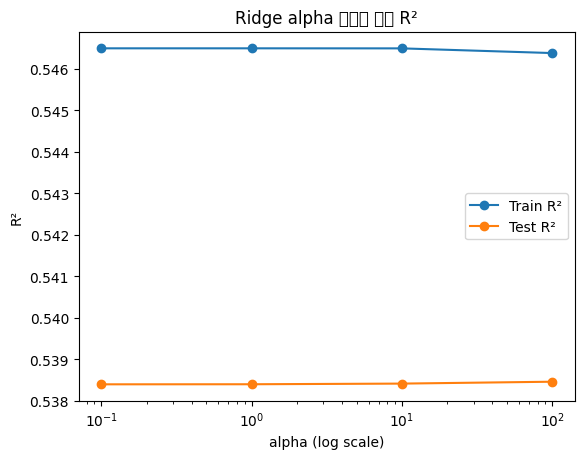

In [6]:
# 여기에 alpha 값 변화에 따른 Ridge 모델의 성능 변화 실험 코드

# [1-4(3)] alpha 값 변화에 따른 Ridge 모델 성능 실험
alpha_values = [0.1, 1, 10, 100]  ## 작은 규제부터 강한 규제까지 로그 느낌으로 체크
alpha_results = []  ## alpha별 train/test R² 저장용

for alpha in alpha_values:
    model = Ridge(alpha=alpha)  ## alpha 커질수록 coefficient 더 강하게 줄임
    model.fit(X_train_poly, y_train)
    alpha_results.append({
        "alpha": alpha,
        "train_r2": model.score(X_train_poly, y_train),  ## train 성능, 너무 높으면 과적합 의심
        "test_r2": model.score(X_test_poly, y_test),  ## test 성능, 실제 비교 기준
    })

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df["gap"] = alpha_results_df["train_r2"] - alpha_results_df["test_r2"]  ## gap으로 과적합 정도 보기
display(alpha_results_df)  ## 표로 먼저 확인

plt.figure()
plt.plot(alpha_results_df["alpha"], alpha_results_df["train_r2"], marker="o", label="Train R²")
plt.plot(alpha_results_df["alpha"], alpha_results_df["test_r2"], marker="o", label="Test R²")
plt.xscale("log")  ## alpha 간격이 0.1~100이라 log scale이 보기 편함
plt.xlabel("alpha (log scale)")
plt.ylabel("R²")
plt.title("Ridge alpha 변화에 따른 R²")
plt.legend()
plt.show()

## 시각화를 위해 AI사용, AI 모델명은 GPT-5.1, // 로그변환에 대한 계산 및 시각화 용이성 최대 주안.

✏️ **[서술형 답변란]** (3) alpha 값 변화에 따른 모델 성능 결과 분석

> 여기에 답변을 작성하시오.

alpha를 0.1, 1, 10, 100으로 바꾸어 실험한 결과 test R²는 각각 약 0.5188, 0.5188, 0.5188, 0.5187로 거의 변하지 않았다. train R²도 약 0.5500 수준에서 alpha=100일 때 0.5499로 아주 조금 낮아졌다.

일반적으로 알파값이 변하면(up) 정규화에 대해 강건해짐으로서, 과적합의 위험성이 줄어든다 피상적으로 이해했으나, 본 실험을 통해 다소 극단적으로 변화를 주었음에도 불구, 영향력이 미미한 점을 미루어 보았을 때, 수업에서 학습한 것처럼 도메인별 다양한 eda를 비롯 - 실험 검증 루프가 필수적이라는 지점을 알 수 있었다. 

---
# Part 2. Classification — Breast Cancer (50점)

**데이터셋:** `sklearn.datasets.load_breast_cancer()`  
**예측 목표:** 악성(0) / 양성(1) 종양 분류

> 이 파트에서는 KNN → SVM → Decision Tree 순서로 구현하고 비교한다.


## 2-1. 데이터 준비 (5점)

아래 작업을 수행하시오.

1. 데이터를 로드하고 DataFrame으로 변환하시오.
2. `shape`, `describe()`, 클래스 분포(`value_counts`)를 출력하시오.
3. train : test = **7 : 3** 으로 분리하시오. (`random_state=42`)
4. `StandardScaler`를 적용하시오. (train으로만 `fit`)


In [ ]:
# [2-1] 데이터 준비
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

import pandas as pd
import numpy as np

# 여기에 코드를 작성하시오

cancer = load_breast_cancer(as_frame=True)
X_bc = cancer.data.copy()  ## 피처, 진단 관련 수치들
y_bc = cancer.target.copy()  ## 타겟: 0=malignant, 1=benign

# 1) 데이터 크기/기술통계 확인 -> feature가 30개라 스케일 차이 큼
print("X shape:", X_bc.shape)
print("y shape:", y_bc.shape)
display(X_bc.describe())

# 2) 클래스 분포 확인 
print("클래스 분포 (0=malignant, 1=benign):")
display(y_bc.value_counts().rename(index={0: "malignant", 1: "benign"})) ##-> 분류는 class imbalance 먼저 체크

# 3) train:test = 7:3, stratify=y로 malignant/benign 비율 유지
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc
)  ## test_size=0.3: 7:3 분할 / random_state=42: 재현가능성용 / stratify: class 비율 보존


# 4) StandardScaler -> KNN/SVM이 스케일 큰 미식별 스케일 피처에 먹히지 않도록 사전 정규화.
bc_scaler = StandardScaler()
X_bc_train_scaled = bc_scaler.fit_transform(X_bc_train)  ## train 기준 fit_transform
X_bc_test_scaled = bc_scaler.transform(X_bc_test)  ## test는 transform만, 일전 1. 과 같이 테스트데이터셋과 학습데이터셋은 분리철저

classification_results = {}  ## **KNN/SVM/DT 결과 모아둘 dict**

print("Train shape:", X_bc_train.shape, "Test shape:", X_bc_test.shape)

#클래스 분포 (0=malignant, 1=benign): Train shape: (398, 30) Test shape: (171, 30)

X shape: (569, 30)
y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


클래스 분포 (0=malignant, 1=benign):


target
benign       357
malignant    212
Name: count, dtype: int64

Train shape: (398, 30) Test shape: (171, 30)


## 2-2. KNN (K-Nearest Neighbors) (13점)

**(1) [6점]** k = 1, 3, 5, 7, 9, 11, 13, 15 에 대해 각각 KNN 모델을 학습하고,  
train accuracy와 test accuracy를 계산한 뒤 **그래프로 시각화**하시오.

**(2) [3점]** 그래프를 바탕으로 **최적의 k 값**을 선택하고, 선택 근거를 설명하시오.  
(힌트: 과적합/underfitting 관점에서 서술)

**(3) [4점]** 아래 질문에 답하시오.
- k가 너무 작을 때(예: k=1) 어떤 문제가 발생하는가?
- k가 너무 클 때 어떤 문제가 발생하는가?
- KNN에서 `StandardScaler`를 반드시 적용해야 하는 이유는 무엇인가?


,k,train_accuracy,test_accuracy
0,1,1.000000,0.935673
1,3,0.984925,0.959064
2,5,0.977387,0.970760
3,7,0.964824,0.964912
4,9,0.967337,0.982456
5,11,0.969849,0.976608
6,13,0.969849,0.976608
7,15,0.967337,0.976608


Best k: 9
Best KNN confusion matrix:
 [[ 61   3]
 [  0 107]]


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


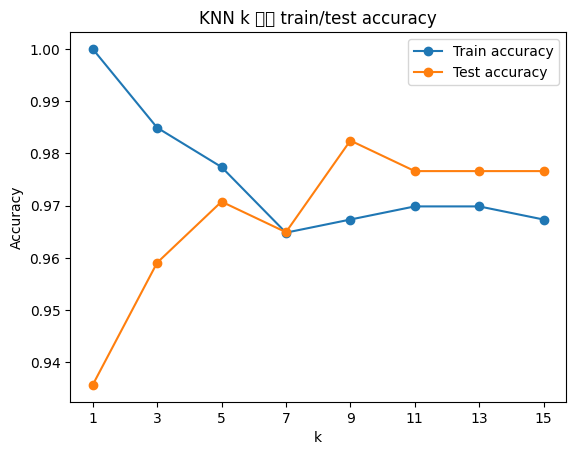

In [8]:
# [2-2-①] KNN — k 값별 accuracy 계산 및 시각화
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11, 13, 15] ## 왜 홀수 k? ->  홀수 k 위주: 동률 줄이고 엣지값 변화 보기
knn_results = []  ## k별 accuracy 저장용

# 여기에 코드를 작성하시오

##1. 요구사항 체크

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)  ## k: 몇 명? 의견 들을지
    knn.fit(X_bc_train_scaled, y_bc_train)  ## KNN은 사실상 데이터 저장으로.
    train_pred = knn.predict(X_bc_train_scaled)  ## train 성능 -> k 너무 작으면 1.0 뜸으로 유의. 
    test_pred = knn.predict(X_bc_test_scaled)  ## test 성능 -> 메인.
    knn_results.append({
        "k": k,
        "train_accuracy": accuracy_score(y_bc_train, train_pred),
        "test_accuracy": accuracy_score(y_bc_test, test_pred),
    })

knn_results_df = pd.DataFrame(knn_results)
best_knn_row = knn_results_df.sort_values(["test_accuracy", "train_accuracy"], ascending=[False, False]).iloc[0]  ## test 우선, 동률이면 train 높은 쪽
best_k = int(best_knn_row["k"])  ## 최적 k 저장, 뒤 모델 비교에서 사용


best_knn = KNeighborsClassifier(n_neighbors=best_k)  ## best k로 최종 KNN 다시 학습
best_knn.fit(X_bc_train_scaled, y_bc_train)
best_knn_pred = best_knn.predict(X_bc_test_scaled)
best_knn_cm = confusion_matrix(y_bc_test, best_knn_pred)  ## FN/FP 보려고 confusion matrix 저장
best_knn_recall_malignant = recall_score(y_bc_test, best_knn_pred, pos_label=0)  ## pos_label=0: 악성을 positive처럼 보고 recall 계산


classification_results["KNN(best k)"] = {
    "model": best_knn,
    "test_accuracy": accuracy_score(y_bc_test, best_knn_pred),
    "malignant_recall": best_knn_recall_malignant,
    "confusion_matrix": best_knn_cm,
    "setting": f"k={best_k}",
}


display(knn_results_df)  ## k별 결과 디스플레이
print("Best k:", best_k)
print("Best KNN confusion matrix:\n", best_knn_cm)

plt.figure()
plt.plot(knn_results_df["k"], knn_results_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(knn_results_df["k"], knn_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN k 값별 train/test accuracy")
plt.xticks(k_values)  ## 후보 k 그대로 x축에 표시
plt.legend()
plt.show()

#Best k: 9
#Best KNN confusion matrix:
# [[ 61   3]
# [  0 107]]

##ai 사용, 그래프 시각화 용이성 최대 주안.

✏️ **[서술형 답변란]** (2) 최적 k 선택 근거

> 여기에 답변을 작성하시오.✏️

실험 결과 test accuracy는 k= 9, 11, 13에서 모두 약 0.982456  가장 높았다. 이 중 코드에서는 test accuracy가 같을 때 train accuracy가 높은 값을 기준으로 k=9를를 최적 k로 선택했다. k=1은 train accuracy가 1.0000으로 완벽하지만 test accuracy는 0.935673이므로, 학습 데이터의 국소 노이즈까지 따라가는 과적합 경향이 있다.

k가 9 이상(초과)으로 커지면 test accuracy가 안정적으로 유지되지만, 너무 큰 k는 결정경계가 지나치게 부드러워져 과소적합의 경향성이 있다. 따라서 이번 후보군에서는 test 성능이 최고이고 k=1처럼 과도하게 훈련 데이터에 붙지 않는 k=9을 선택하는 것이 합리적이라 판단하였다.

✏️ **[서술형 답변란]** (3) KNN 원리 해석

> 여기에 답변을 작성하시오.

k가 너무 작으면, 예를 들어 k=1처럼 가장 가까운 샘플 하나만 보고 분류하게 된다. 이 경우 학습 데이터의 노이즈나 우연한 위치에 매우 민감해져 train accuracy는 높지만 새로운 데이터에서는 성능이 떨어지는 과적합이 발생할 수 있다.

반대로 k가 너무 크면 너무 많은 이웃을 평균적으로 반영하므로, 국소적적 클래스 경계를 놓칠 수 있다. 그러면 결정경계가 지나치게 단순해지고 다수 클래스 방향으로 치우쳐 과소적합의 위험성이 대두되는 것을 알 수 있었다.

KNN은 거리 기반 모델이므로 StandardScaler가 중요하다. feature마다 단위와 범위가 다르면 값의 스케일이 큰 feature가 거리 계산에 주요 비중을 차지하여, 실제로 중요한 패턴 즉 상광관계보다- 단위 차이가 분류 결과를 좌우한다. 따라서 train set에 scaler를 fit하고 train/test에 동일하게 transform하여 거리 계산 기준을 맞추어야 한다. 즉, 전처리와 정규화 - 그리고 지속적인 eda를 통해 여부를 확인하고 판단함을 요구한다.

## 2-3. SVM (Support Vector Machine) (14점)

**(1) [8점]** `Pipeline`을 사용하여 아래와 같이 SVM 모델을 구현하고 test accuracy를 출력하시오.

```python
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(C=1, loss='hinge', max_iter=10000))
])
```

이후 C = 0.01, 0.1, 1, 10, 100 으로 변경하며 train/test accuracy를 계산하고 **그래프로 시각화**하시오.

**(2) [6점]** 아래 질문에 답하시오.
- SVM에서 **마진(margin)** 과 **서포트 벡터(support vector)** 의 의미를 설명하시오.
- C 값이 커질수록 모델에 어떤 변화가 생기는가? 본인의 실험 결과와 연결하여 설명하시오.



,C,train_accuracy,test_accuracy
0,0.01,0.979899,0.976608
1,0.10,0.987437,0.976608
2,1.00,0.989950,0.964912
3,10.00,0.992462,0.959064
4,100.00,1.000000,0.941520


SVM(C=1) test accuracy: 0.9649122807017544
SVM(C=1) confusion matrix:
 [[ 60   4]
 [  2 105]]


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


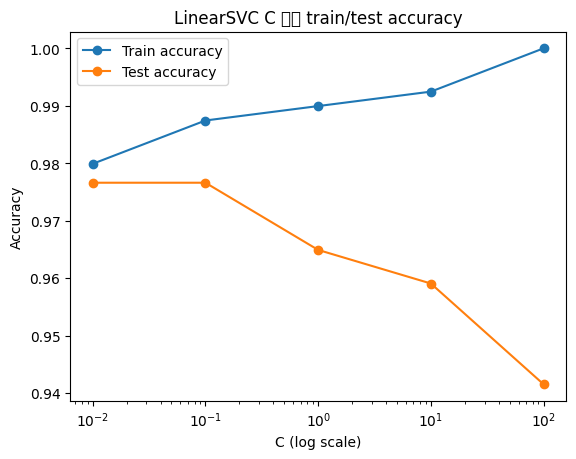

In [9]:
# [2-3-①] SVM — Pipeline 구현 및 C 값 실험
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1, 10, 100] ## C 작음? ->margin 여유, || C 큼->오분류 덜 허용
svm_results = []  ## C별 점수 저장용
svm_models = {}  ## 나중에 C=1 모델 꺼내려고 저장

# 여기에 코드를 작성하시오

for C in C_values:
    svm = Pipeline([
        ("scaler", StandardScaler()),  ## Pipeline 안에서 scaling, 실수 방지용
        ("svc", LinearSVC(C=C, loss="hinge", max_iter=10000, random_state=42, dual=True)),  ## max_iter=10000: 수렴 좀 더 기다림
    ])
    svm.fit(X_bc_train, y_bc_train)  ## Pipeline이라 raw X 넣어도 내부에서 scaler 먹힘
    train_pred = svm.predict(X_bc_train)
    test_pred = svm.predict(X_bc_test)
    svm_results.append({
        "C": C,
        "train_accuracy": accuracy_score(y_bc_train, train_pred),
        "test_accuracy": accuracy_score(y_bc_test, test_pred),
    })
    svm_models[C] = svm

svm_results_df = pd.DataFrame(svm_results)
svm_c1 = svm_models[1]  ## 문제 기준 C=1 모델, 비교표에 넣을 대표 SVM
svm_c1_pred = svm_c1.predict(X_bc_test)
svm_c1_cm = confusion_matrix(y_bc_test, svm_c1_pred)  ## FN/FP 확인용
svm_c1_recall_malignant = recall_score(y_bc_test, svm_c1_pred, pos_label=0)  ## 악성 놓침 줄이는지 체크
classification_results["SVM(C=1)"] = {
    "model": svm_c1,
    "test_accuracy": accuracy_score(y_bc_test, svm_c1_pred),
    "malignant_recall": svm_c1_recall_malignant,
    "confusion_matrix": svm_c1_cm,
    "setting": "C=1",
}

display(svm_results_df)  ## C별 train/test accuracy 디스플레이이
print("SVM(C=1) test accuracy:", classification_results["SVM(C=1)"]["test_accuracy"])
print("SVM(C=1) confusion matrix:\n", svm_c1_cm)

plt.figure()
plt.plot(svm_results_df["C"], svm_results_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(svm_results_df["C"], svm_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xscale("log")  ## C가 0.01~100이라 log scale이 보기 편함
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("LinearSVC C 값별 train/test accuracy")
plt.legend()
plt.show()

##SVM(C=1) test accuracy: 0.9649122807017544

#SVM(C=1) confusion matrix:
 #[[ 60   4]
 #[  2 105]]

##ai 사용, 그래프 시각화 용이성 최대 주안.

✏️ **[서술형 답변란]** (2) SVM 원리 해석

> 여기에 답변을 작성하시오.
✏️ **[서술형 답변란]** (2) SVM 원리 해석

SVM에서 margin은 결정경계와 가장 가까운 학습 샘플들 사이의 여유 폭을 의미한다. 
Support vector는 이 margin 경계 근처에 놓여 실제 결정경계의 위치를 정하는 핵심 샘플이다. 

SVM은 단순히 학습 데이터를 맞히는 선을 찾는 것이 아니라, 가능한 한 margin이 넓은 경계를 찾아 일반화 성능을 높이려는 모델이다.

C 값은 오분류 또는 margin 침범에 대한 penalty 강도를 조절한다. C가 작으면 오분류를 어느 정도 허용하면서 넓은 margin을 선호하고, C가 커지면 - 훈련 데이터를 더 엄격하게 맞추려 하므로 margin이 좁아지고 과적합 위험이 커질 수 있다. 

이번 실험에서는 C=[0,1]에서 test accuracy가 약 0.976608 로 가장 높았고, C=10과 100에서는 train accuracy는 증가했지만 test accuracy가 각각 약 0.941520로 떨어졌다. 이는 C가 너무 커질 때 일반화 성능이 나빠질 수 있음을 보여준다.

## 2-4. Decision Tree (13점)

**(1) [6점]** 아래 두 기준으로 각각 Decision Tree를 학습하고 test accuracy를 비교하시오.

```python
from sklearn.tree import DecisionTreeClassifier

clf_gini    = DecisionTreeClassifier(criterion="gini",    max_depth=5, min_samples_leaf=3, random_state=42)
clf_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, min_samples_leaf=3, random_state=42)
```

각 모델에 대해 `classification_report`를 출력하고, `tree.plot_tree()`로 트리를 시각화하시오.

**(2) [4점]** 아래 질문에 답하시오.
- **Gini impurity** 와 **Entropy** 의 차이를 설명하시오.
- 두 기준의 결과를 비교하고, 어떤 기준이 이 데이터에 더 적합한지 수치 근거와 함께 설명하시오.

**(3) [3점]** `max_depth=5`, `min_samples_leaf=3` 으로 설정된 상태에서 `max_depth=None` 등 설정을 변경하면 어떤 결과가 나오는지 실험하고 해석하시오.


,criterion,train_accuracy,test_accuracy,malignant_recall
0,gini,0.979899,0.906433,0.921875
1,entropy,0.984925,0.953216,0.937500


[Gini] classification_report
              precision    recall  f1-score   support

   malignant       0.84      0.92      0.88        64
      benign       0.95      0.90      0.92       107

    accuracy                           0.91       171
   macro avg       0.90      0.91      0.90       171
weighted avg       0.91      0.91      0.91       171

[Entropy] classification_report
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        64
      benign       0.96      0.96      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Gini confusion matrix:
 [[59  5]
 [11 96]]


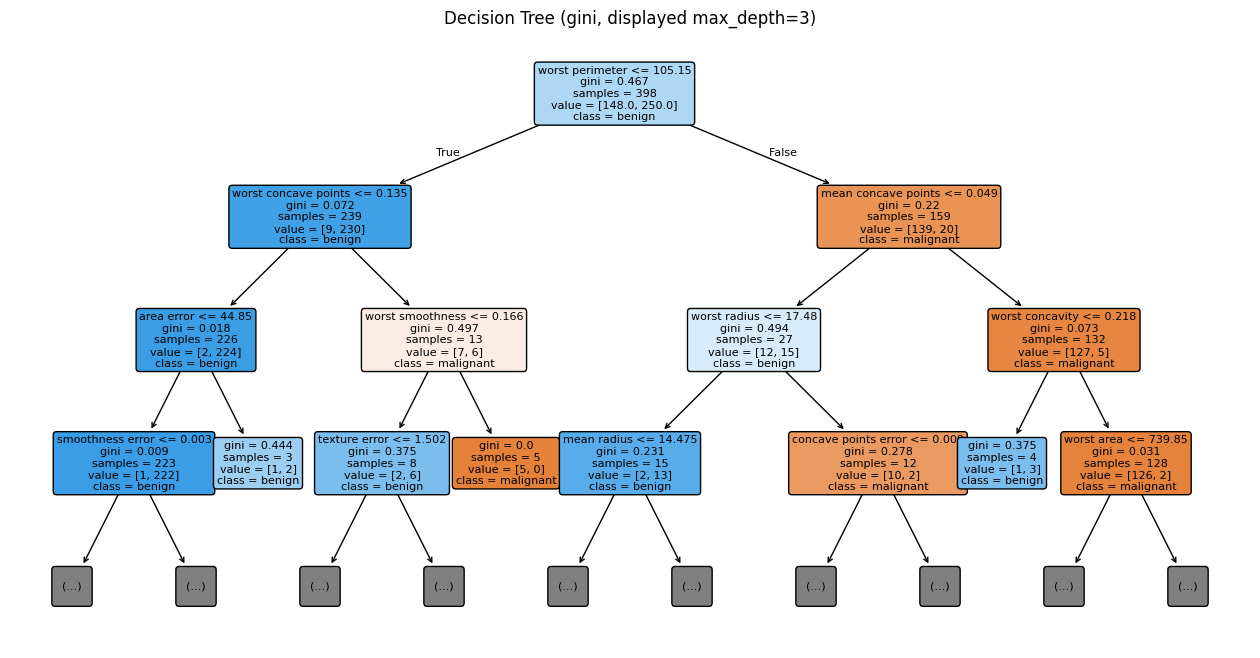

In [ ]:
# [2-4-①] Decision Tree — gini vs entropy 비교
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# gini / entropy만 다르게 두고 나머지 파라미터는 동일하게 -> 기준만 비교.
clf_gini = DecisionTreeClassifier(
    criterion="gini", max_depth=5, min_samples_leaf=3, random_state=42
)  ## max_depth=5: 너무 깊게 자라지 않게, min_samples_leaf=3: leaf에 최소 샘플 3개
clf_entropy = DecisionTreeClassifier(
    criterion="entropy", max_depth=5, min_samples_leaf=3, random_state=42
)  ## entropy: 정보량 감소 기준, gini와 비교용

clf_gini.fit(X_bc_train, y_bc_train) ## Breast Cancer는 앞에서 StandardScaler를 썼던 데이터(X_bc_train_scaled)가 있었으나, DT는 거리/스케일에 민감하지 않을 것으로 판단하였음.
clf_entropy.fit(X_bc_train, y_bc_train)

##예측가능성 / 정확성. accuracy와 malignant recall용 테이블 준비.
gini_train_pred = clf_gini.predict(X_bc_train)
gini_test_pred = clf_gini.predict(X_bc_test)
entropy_train_pred = clf_entropy.predict(X_bc_train)
entropy_test_pred = clf_entropy.predict(X_bc_test)

# 수치 근거 만들기: accuracy + malignant recall 같이 봄.
dt_results_df = pd.DataFrame([
    {
        "criterion": "gini",
        "train_accuracy": accuracy_score(y_bc_train, gini_train_pred),
        "test_accuracy": accuracy_score(y_bc_test, gini_test_pred),
        "malignant_recall": recall_score(y_bc_test, gini_test_pred, pos_label=0), ## 악성(malignant)을 pos_label=0 체크
    },
    {
        "criterion": "entropy",
        "train_accuracy": accuracy_score(y_bc_train, entropy_train_pred),
        "test_accuracy": accuracy_score(y_bc_test, entropy_test_pred),
        "malignant_recall": recall_score(y_bc_test, entropy_test_pred, pos_label=0), ##상동
    },
])

## -> 이후  2-4(2) 서술형 근거절


gini_cm = confusion_matrix(y_bc_test, gini_test_pred)  ## FN/FP 확인용, gini DT 대표값
classification_results["DT(gini)"] = {
    "model": clf_gini,
    "test_accuracy": accuracy_score(y_bc_test, gini_test_pred),
    "malignant_recall": recall_score(y_bc_test, gini_test_pred, pos_label=0),
    "confusion_matrix": gini_cm,
    "setting": "criterion=gini, max_depth=5, min_samples_leaf=3",
}

display(dt_results_df)  ## gini vs entropy 디스플레잉
print("[Gini] 분류보고")
print(classification_report(y_bc_test, gini_test_pred, target_names=cancer.target_names))
print("[Entropy] 분류보고")
print(classification_report(y_bc_test, entropy_test_pred, target_names=cancer.target_names))
print("Gini confusion matrix:\n", gini_cm)

plt.figure(figsize=(16, 8))  ## 트리 그림은 넓게 봐야.. 글씨 안 터짐
plot_tree(
    clf_gini,
    feature_names=X_bc.columns,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    max_depth=3,  ## 시각화만 3단계 제한, 전체 트리 다 보면 너무 복잡.
    fontsize=8,
)
plt.title("Decision Tree (gini, displayed max_depth=3)")
plt.show()

##Gini confusion matrix:

# [[59  5]
# [11 96]]

##AI 사용, plt.figure(figsize=(16, 8)) 에서 FIGSIZE DT 시각화에 사용, 모델 : CLAUDE 4.6

✏️ **[서술형 답변란]** (2) Gini vs Entropy 해석

Gini impurity와 Entropy는 둘 다 노드 안에 class가 얼마나 섞여 있는지 보는 지표인데, 계산이 조금 단순하여 CART에서 기본값으로 많이 사용되고, Entropy는 정보량/불확실성 감소에 중점을 둔다. 결국 "어떻게 분기기 후 자식 노드가 보다 명료하게 분류되었는가"를 보는 2가지 분류방법이다.

본 모델델에서는 gini 기준 Decision Tree와 entropy 기준 Decision Tree를 같은 max_depth=5, min_samples_leaf=3, random_state=42 로 비교하였다. 수치상으로 test accuracy와 malignant recall에 유의하여, 특히 의료 데이터 도메인을 의식하고 단순 accuracy보다 악성 class를 얼마나 놓치지 않는지, 즉 malignant recall을 더 중요하게 보았음에도 불구하고, 0.921875 | 0.937500 으로써 유의미한 결과가 도출되진 않은 것 같다.

따라서 두 기준 중 어떤 것이 더 낫다고 단정하기보다는, 현재 test 결과에서 accuracy와 malignant recall이 더 안정적인 쪽을 선택하는 것이 맞다고 보여진다. 다만 Decision Tree 자체는 깊어질수록 train data를 너무 강하게 반영하는- 샘플 데이터에에 과적합 위험이 있으므로, gini/entropy 기준보다는 depth 와 같은 통제변수를 메인으로 복잡도 조절에 보다 초점을 두어 유의해야 할 것 같다. 

특히, 이러한 의료 도메인과 타 도메인은 굉장히 차이가 있을 것이므로, 동일한 프레임워크나 방법론에 대하여 확증적 편향을 주의하고 유동적으로 타겟에 대해 변동 양상을 파악하는 것이 중요할 것으로 생각된다.

,max_depth,min_samples_leaf,train_accuracy,test_accuracy,gap,malignant_recall
0,3,1,0.972362,0.923977,0.048385,0.921875
1,3,3,0.972362,0.929825,0.042537,0.906250
2,3,5,0.967337,0.923977,0.043360,0.906250
3,5,1,1.000000,0.935673,0.064327,0.921875
4,5,3,0.979899,0.906433,0.073467,0.921875
5,5,5,0.967337,0.935673,0.031664,0.921875
6,None,1,1.000000,0.935673,0.064327,0.921875
7,None,3,0.979899,0.906433,0.073467,0.921875
8,None,5,0.967337,0.935673,0.031664,0.921875


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


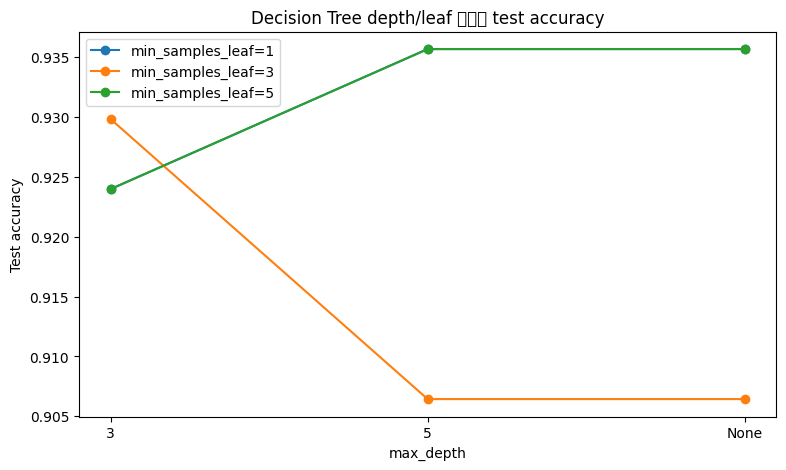

In [18]:
# [2-4-③] max_depth / min_samples_leaf 설정 바꿔보기
depth_values = [3, 5, None] ## 3=얕게, 5=문제 기본, None=끝까지.
leaf_values = [1, 3, 5] ## leaf  샘플 하한, 클수록 극소소 노이즈 분기 방지
dt_tuning_results = [] ## 조합별 결과 저장용

for depth in depth_values:
    for leaf in leaf_values:
        model = DecisionTreeClassifier(
            criterion="gini",
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42,
        )
        model.fit(X_bc_train, y_bc_train)
        train_pred = model.predict(X_bc_train)
        test_pred = model.predict(X_bc_test)
        dt_tuning_results.append({
            "max_depth": "None" if depth is None else depth,  ## None은 제한 없음, 과적합 체크용
            "min_samples_leaf": leaf,
            "train_accuracy": accuracy_score(y_bc_train, train_pred),
            "test_accuracy": accuracy_score(y_bc_test, test_pred),
            "gap": accuracy_score(y_bc_train, train_pred) - accuracy_score(y_bc_test, test_pred),  ## gap 크면 과적합 냄새
            "malignant_recall": recall_score(y_bc_test, test_pred, pos_label=0),  ## 악성 놓침 체크
        })

dt_tuning_results_df = pd.DataFrame(dt_tuning_results)
display(dt_tuning_results_df)  ## depth/leaf 조합별 성능 디스플레이

plt.figure(figsize=(9, 5))
for leaf in leaf_values:
    subset = dt_tuning_results_df[dt_tuning_results_df["min_samples_leaf"] == leaf]
    plt.plot(
        subset["max_depth"].astype(str),
        subset["test_accuracy"],
        marker="o",
        label=f"min_samples_leaf={leaf}",
    )
plt.xlabel("max_depth")
plt.ylabel("Test accuracy")
plt.title("Decision Tree depth/leaf 설정별 test accuracy")
plt.legend()
plt.show()

✏️ **[서술형 답변란]** (3) max_depth, min_samples_leaf 설정 근거
>
'max_depth' 는 트리가 얼마나 깊게 자랄 수 있는지 정하는 파라미터이고, 'min_samples_leaf'는 leaf node에 최소 몇 개의 샘플을 남길지 정하는 파라미터다. 'max_depth=None'처럼 제한을 풀면 train accuracy는 올라가기 쉽지만, 데이터의 노이즈까지 쪼개서 과적합이 발생한다.

반대로 'min_samples_leaf'를 크게 잡으면 leaf 하나가 너무 작은 샘플만 보고 만들어지는 것을 막을 수 있다. 즉 모델이 다소 강건해진다 볼 수 있으며, test data에 대한 안정성이 올라갈 수 있다. 본 모델에서는, train/test accuracy gap과 malignant recall을 같이 볼 시에, 단순히 train accuracy가 높은 설정보다 test에서 안정적인 설정이 더 의미 있다고 보여진다.

하여, Decision Tree는 해석이 쉬운 장점이 있지만, 어느 max min 등, 파라미터에 대해 구체적 모델링의 병행이 필수적이며, 상시 과적합을 경계해야하는 모델로 인식될 수 있다.

## 2-5. 성능 분석 및 모델 비교 (5점)

**(1) [2점]** 최적 k의 KNN, C=1의 SVM, gini DT 세 모델의 test accuracy를 하나의 표로 정리하시오.

**(2) [3점]** 아래 질문에 답하시오.
- 이 데이터(유방암 진단)에서 **False Negative(FN)** 와 **False Positive(FP)** 중 어느 쪽이 더 위험한가?  
  이유를 의학적 관점에서 설명하시오.
- Accuracy 하나만으로 모델 성능을 판단하는 것이 부적절한 이유를 설명하시오.


In [20]:
#[2-5-①] 세 모델 성능 비교 표

#$ KNN(best k), SVM(C=1), DT(gini)를 한 표로 비교.
model_comparison = pd.DataFrame([
    {
        "model": name,
        "setting": info["setting"],
        "test_accuracy": info["test_accuracy"],
        "malignant_recall": info["malignant_recall"],
        "confusion_matrix_[0,1;0,1]": info["confusion_matrix"].tolist(),
    }
    for name, info in classification_results.items()
])

best_accuracy_model = model_comparison.sort_values("test_accuracy", ascending=False).iloc[0]
best_recall_model = model_comparison.sort_values("malignant_recall", ascending=False).iloc[0]

display(model_comparison)  ## 제출용 비교표 디스플레잉잉
print("Accuracy 기준 최고 모델:", best_accuracy_model["model"], best_accuracy_model["test_accuracy"])
print("악성 recall 기준 최고 모델:", best_recall_model["model"], best_recall_model["malignant_recall"])


,model,setting,test_accuracy,malignant_recall,"confusion_matrix_[0,1;0,1]"
0,KNN(best k),k=9,0.982456,0.953125,"[[61, 3], [0, 107]]"
1,SVM(C=1),C=1,0.964912,0.937500,"[[60, 4], [2, 105]]"
2,DT(gini),"criterion=gini, max_depth=5, min_samples_leaf=3",0.906433,0.921875,"[[59, 5], [11, 96]]"


Accuracy 기준 최고 모델: KNN(best k) 0.9824561403508771
악성 recall 기준 최고 모델: KNN(best k) 0.953125


✏️ **[서술형 답변란]** (2) FN/FP 해석 및 Accuracy 한계

Breast Cancer 진단에서는 False Negative(FN)가 False Positive(FP)보다 더 위험하다고 생각되는데, 본 도메인의 데이터에서 0은 malignant(악성), 1은 benign(양성)이므로, FN은 실제 악성인데 모델이 양성으로 예측해서 놓치는 경우으로 해석할 수 있다. 이 경우 치료나 추가 검사가 늦어질 수 있으므로, FP보다 리스크가 매우 크다고 보여진다.

반면 FP는 실제 양성인데 악성으로 의심하는 경우라 추가 검사, 불안, 비용이 발생할 것이다. 물론 FP도 문제지만, 의료 도메인에서는 악성을 놓치는 FN의 비용이 더 크다고 보는 것이 자연스럽다.

따라서 도메인별로 너무 다르다. 지식의 저주라는 말처럼, 데이터사이언티스로서, 단순 통계적 수치만을 보고 특정 도메인에 대한 패턴을 파악하기에는 너무도 위험하다. 미식별된 통제변수가 - 심지어는 사회과학적, 맥락적인 요소가 잔존해있다는 것을 염두에 두어야할 것이다. 

본 유방암에서 사실 가장 FP와 NP의 벨류를 판별함에 중요한 것은 어떤 분류 기법을 사용하는 기술적 방법론이 아닌, 결국 어디에 초점을 두어야하는 것이었는데, 이때 가장 주안이 된 것은 수치적으로 나타나지 않았던 '골든타임'이란 외재변수였다. 이처럼, 모델링에서 나온 accuracy 하나만 보면 부족하다. accuracy는 전체 정답률만 보여주고, 어떤 오류가 더 위험한지 반영하지 않는다. 그래서 confusion matrix, malignant recall, precision, F1-score를 같이 보되 매몰되지 않는, 거시적 접근이 특히 중요하다 생각한다.

(*마지막에서 부연하겠습니다*)

---
# Part 3. 종합 분석 (15점)


## 3-1. Regression vs Classification 비교 (5점)

**(1) [2점]** Regression과 Classification의 근본적인 차이를 아래 두 관점에서 설명하시오.
- 예측값(output)의 형태
- 주요 평가지표

**(2) [3점]** California Housing 데이터의 `MedHouseVal`을 기준으로  
"고가(상위 50%) / 저가(하위 50%)" 로 이진 분류 문제로 변환한다고 가정하자.  
이렇게 문제를 변환할 때의 **장점 1가지**와 **단점 1가지**를 구체적으로 서술하시오.


✏️ **[서술형 답변란]** (1) Regression vs Classification

Regression은 연속적인 숫자값을 예측하는 문제다. 예를 들어 California Housing의 *MedHouseVal*처럼 주택 중위 가격을 직접 예측하는 경우가 이에 해당한다. 출력값이 숫자이므로 R'2, MSE, RMSE, MAE 같은 지표로 실제값과 예측값의 차이를 본다.

Classification은 미리 정해진 클래스 라벨을 예측하는 문제다. Breast Cancer처럼 malignant/benign을 나누는 경우가 해당된다. 출력값이 범주이므로 accuracy, confusion matrix, precision, recall, F1-score 등을 사용한다.

즉 Regression은 "연속형 - 수치형"을 예측하는 문제이고, Classification은 "어느 범주인가"를 예측하는 문제라고 정리할 수 있다.

✏️ **[서술형 답변란]** (2) 문제 변환 장단점

California Housing의 'MedHouseVal'을 median 기준으로 상위 50%는 고가, 하위 50%는 저가로 나누면 회귀 문제가 이진 분류 문제로 바뀐다. 장점은 의사결정이 단순해진다는 점으로 볼 수 있다. 정확한 가격을 맞히는 대신, 이 집이 상대적으로 고가인지 저가인지만 판단하면 되므로 추천, 필터링, 우선순위 판단에는 더 직관적인 의사결정에 인사이트를 제공할 수 있다.

단점은 정보 손실이다. 원래 'MedHouseVal'은 연속형의 가격 정보인데, 이진 분류로 바꾸면 median보다 얼마나 높은지 낮은지의 차이가 사라진다. 예를 들어 median보다 아주 조금 높은 집과 매우 비싼 집이 모두 같은 고가 class가 된다.

또한 threshold를 median으로 잡는 것도 임의적이다. median 근처 샘플들은 작은 데이터 변화만으로 class가 바뀔 수 있다. 그래서 문제를 단순화하는 장점은 있지만, 가격의 세밀한 차이를 보는 분석에는 회귀가 더 적절할 수 있다. 

따라서, 정리하면, 문제 변환의 장단점으로 국소적으로는 볼 수 있으나, 데이터를 활용하여 모델링하고 이를 바탕으로 학습-예측하여 때로는 통계적 근거로서, 때로는 표본으로서 모집단에 대한 근사로서 각기 적재적소에 사용함이 맞을 듯 하다.

 연속형과 연속형을 범주형과 범주형으로 치환하여 상호 독립성을 검정하고, 각각에 대하여 범주형을 연속형으로 변환후 ANOVA, 이후 연속형과 연속형으로 변환하여 PCA로서 시각화후 지속적으로 다차원 검증함에 있어 그 시작은 각 범주형과 연속형의 장/단점을 적절히 사용함에서 기인한다 생각하기 때문이다.

## 3-2. 최적 모델 선택 (5점)

KNN, SVM, Decision Tree 중 **Breast Cancer 진단에 가장 적합한 모델**을 선택하고,  
아래 세 가지 관점을 모두 포함하여 근거를 서술하시오.

- **성능 (Accuracy, FN 관점)**
- **해석 가능성 (의사/환자에게 설명 가능한가)**
- **일반화 (새로운 환자 데이터에 대한 신뢰도)**


✏️ **[서술형 답변란]** 최적 모델 선택 및 근거

앞의 2-5(2)에서 정리한 것처럼, Breast Cancer 진단에서는 accuracy만 높은 모델을 고르면 위험하다. 이 문제는 악성 종양을 양성으로 놓치는 FN 비용이 훨씬 크기 때문에, *`C_FN * FN + C_FP * FP` 같은 비용함수*관점에서 볼 시에는 *C_FN* 에 더 큰 가중치를 주는 방향이 맞다고 생각된다. 따라서 3-2의 모델 선택도 accuracy 1개가 아니라, confusion matrix와 malignant recall을 같이 보는 흐름으로 이어지면 자연스러울 것으로 생각한다.

분리하여, 이번 모데링 결과값만을 집합으로 볼 시에는는, 가장 우선시로서는 KNN(best k=9)으 선택하는 것이 자연스러울 것으로 보여진다다. KNN은 test accuracy가 약 `0.9825`로 가장 높았고, confusion matrix도 *[[61, 3], [0, 107]]*으로 나타났다. 

반면 SVM(C=1)은 test accuracy가 약 `0.9649`이고 confusion matrix가 *[[60, 4], [2, 105]]*인데, 이때 -KNN의 실제 malignant 64개 중 3개를 benign으로 놓쳤으므로 malignant recall을 기준으로 비교하여도 KNN은 약 `0.9531`으로, SVM 악성을 놓친 FN이 4개로 KNN보다 조금 많다. 

하여, 단순 정답률뿐 아니라 FN 비용 관점, 그리고 본 결과 해석에서도 이번 split에서는 KNN이 더 안정적인 후보로 보인다.


## 3-3. 실무 적용 시 고려사항 (5점)

성능이 높은 모델이라도 실제 병원에 도입하기 어려운 이유가 있다.  
아래 두 관점에서 각각 구체적인 문제점을 1가지씩 서술하시오.

- **기술적 관점** (예: 데이터 품질, 모델 업데이트, 편향 등)
- **윤리·법적 관점** (예: 오진 책임, 개인정보, 설명 의무 등)
- *추가 기술적 관점* : (도메인 영역에 관한 데이터 편향성에 대해 최적 함수 모델 근사 아이데이션을 적어보았습니다.)


✏️ **[서술형 답변란]** 기술적 관점

1) 기술적 관점에서는 학습 데이터와 실제 병원 데이터가 다를 수 있다는 점이 가장 크다. 

공개 Breast Cancer 데이터셋에서는 성능이 높게 나와도, 실제 병원에서는 장비, 측정 방식, 환자군, 입력 데이터 품질이 다를 수 있다. 이런 distribution shift가 생기면 test accuracy가 높았던 모델도 실제 환경에서는 성능이 떨어질 수 있다.

또한 의료 데이터는 결측치, 측정 오류, 라벨 오류가 생길 수 있다. 시간이 지나면서 진단 기준이나 장비도 바뀔 수 있으므로, 모델을 한 번 학습하고 끝내기보다는 지속적인 성능 모니터링과 업데이트가 필요하다.

2) 
추가적으로, 관측된 feature만으로 설명되지 않는 외부 요인도 있을 수 있다. 

예를 들어 환자의 병력, 병원 검사 프로토콜, 장비 차이 같은 요소는 데이터에 직접 안 들어와도 결과에 영향을 줄 수 있다. 이런 부분은 latent factor처럼 간접적으로 근사해보는 방향도 가능할 것 같다 생각한다.

(*마지막에서 부연하겠습니다*)

✏️ **[서술형 답변란]** 윤리·법적 관점

윤리·법적 관점에서는 책임과 설명 의무가 중요하다 생각하는데, 모델이 악성 환자를 양성으로 잘못 예측하면 치료가 늦어질 수 있는데, 이때 책임이 병원, 의사, 모델 개발자 중 누구에게 있는지 불명확할 수 있다. 따라서, 보다 설명력이 강한 - 최소한 파라미터로서 통제가능하며 재현 가능성이 타 모델보다 우위를 점하는 - DT 계열의 모델을 사용하여 이를 보장하는 것이 유리할 것으로 보여진다.

또한 의료 데이터는 개인정보이므로 수집, 저장, 학습 과정에서 보안과 동의 문제가 할 것으로 보인다. 

결국 의료 모델은 accuracy가 높다는 이유만으로 바로 도입하기 어렵다. FN/FP 비용, 설명가능성, 개인정보, 책임 소재까지 같이 고려해야 실제 병원 시스템에 적용할 수 있다.

✏️ - *추가 기술적 관점* : (도메인 영역에 관한 데이터 편향성에 대해 최적 함수 모델 근사 아이데이션을 적어보았습니다.)


이번, 4/24일, WIT 2026에서 금오공과대학 ai로보틱스 연구실 교수님과 나눈 말씀에서 실마리를 얻었습니다.

2-4에서 이어본다면, Breast Cancer 진단에서 FN은 골든타임 상실과 생존율 악화로 연결되는 치명적 오류이고, FP는 추가 검사와 심리·경제적 부담을 유발하는 비교적 덜 치명적인 오류로 해석할 수 있습니다. 
특히, FN의 진짜 비용은 단순히 한 번의 오진이 아니라, 시간에 따라 악화되는 병의 진행과 골든타임 상실에 의하여 결정되는 본 요소는, 사전에 수집한 또는 현재 데이터셋의 정적인 feature만으로는 직접 관측되기 어려우며 자연과학적 접근보다는 사회과학학적 외재변수로 주어지는 것처럼 보입니다. 

따라서 모델 선택 기준은 단순 Accuracy 최대화가 아니라, FN/FP에 서로 다른 비용을 부여한 비용 민감(cost‑sensitive) 목적함수로 두면, 결과적으로 malignant recall(악성 민감도)를 우선시하는 분류기가 결과적으로 도출 및 선택될 것으로 볼 수 있을 것 같다 생각하였습니다. 

전통적인 통계 모형에서는 앞서 말한 요인들이 모형 밖에 남아 있는 외재변수로 간주되거나, 단순한 잡음·오차항에 흡수되었지만, 최근 빅데이터와 representation learning 관점에서는 이들을 잠재 요인(latent factor)으로 근사하여 모형 안으로 끌어들이고, 사실상 통제변수와 유사한 역할을 하도록 설계할 수 있지 않을까란 생각을 해보았는데, 이를 위해 관측 feature X와 외재변수를 통계적으로 근사한 U^를 바탕으로 잠재공간 z=ϕ(X,U^)를 도출하고, 현시성을 바탕으로한 데이터에 대해 해당 공간에서 비용 민감 목적함수를 최적화하는 방식의 도메인 최적 모델을 생각해보았습니다.

환자의 상태가 시간에 따라 변화하는 시계열 데이터나 치료 경로 데이터가 주어진다면, Koopman operator 기반의 latent dynamics 프레임을 도입하여 Z𝑡+1=Kzt 와 같이 잠재공간에서의 선형 동역학을 학습하고, 각 시점의 FN/FP가 미래 상태와 골든타임 상실에 미치는 영향을 장기적인 비용 함수로 통합할 수 있다면, 모델 선택 기준은 단순 Accuracy 최대화가 아니라, FN/FP에 서로 다른 비용을 부여한 비용 민감(cost‑sensitive) 목적함수로 도출될 수 있을 것으로 생각됩니다.

본 과제의 노트북은 이러한 Koopman 모델을 직접 구현한 것은 아니지만, confusion matrix와 malignant recall을 함께 분석한 구조는 향후 이러한 latent representation·Koopman 프레임으로 확장될수 있지 않을까란 기대를 해보았습니다만, 배움이 부족하여 보다 학습 후 기말고사로 뵙길 바라며 본 시험을 마치겠습니다.


`26.04.28, 데이터사이언스 융합전공 / C293085 류지환 제출.`